In [64]:
import glob
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

In [65]:
map_paths = glob.glob("./data/TrainingData/*/cloud.ply")

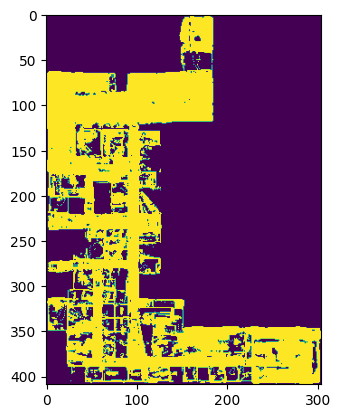

In [59]:
def generate_map(filepath, reso = 0.2, thre = 0.2):
    pc = o3d.io.read_point_cloud(filepath)
    upper_bounds = np.max(pc.points, axis = 0)
    lower_bounds = np.min(pc.points, axis = 0)

    map_shape = np.ceil((upper_bounds - lower_bounds)/reso).astype(np.int64)
    map_np = np.zeros((map_shape[0], map_shape[1]))
    for point in pc.points:
        x, y, _ = ((point - lower_bounds)//reso).astype(np.int64)

        if point[2] >= thre:
            map_np[x,y] = 1
    return map_np
map_np = generate_map(map_pc[1])
plt.imshow(map_np)
plt.show()

In [68]:
for map_path in map_paths:
    env_name = map_path.split('/')[-2]
    map_np = generate_map(map_path)
    np.save('./maps/'+env_name+'.npy', map_np)

In [66]:
map_paths[0].split('/')

['.', 'data', 'TrainingData', 'Matterport_tilt', 'cloud.ply']